# 09 — Human Evaluation of Explanation Quality

**Purpose:** Evaluate 100 BGL + 100 HDFS explanations on four dimensions via manual review.

**Current run:** GPT-5.1 full results (BGL 6,295 sessions / HDFS 2,527 sessions)

**Rubric (Likert 1-5):**

| Dimension | 1 | 3 | 5 |
|-----------|---|---|---|
| **Correctness** | Explanation contradicts the logs | Partially correct, minor errors | Fully accurate description of the anomaly |
| **Completeness** | Major anomaly signals missing | Covers main signal, misses secondary | All anomaly signals addressed |
| **Evidence Grounding** | Claims cite wrong or no evidence | Most claims grounded, some vague | Every claim backed by correct evidence span |

**Binary:**
| Dimension | Y | N |
|-----------|---|---|
| **Actionable** | An engineer could act on this explanation | Too vague or wrong to act on |

**Workflow:**
1. Run Sections 1-3 once (Section 2 is slow — loads raw logs, cached after first run)
2. Section 4: evaluating — change `IDX`, view session, fill in `rate()`, run
3. Section 5: progress check
4. Section 6: analysis (run after all 100 sessions rated)


In [17]:
import sys, json, math, random
from pathlib import Path
from collections import Counter
from datetime import datetime

import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

# === Constants ===
SAMPLE_SIZE = 100
SEED = 42

# GPT-5.1 full run results
RESULT_FILES = {
    'BGL':  PROJECT_ROOT / 'results' / 'explanations_BGL_20260301_112519.jsonl',
    'HDFS': PROJECT_ROOT / 'results_HDFS' / 'explanations_HDFS_20260303_162016.jsonl',
}

PREPARED_PATH = PROJECT_ROOT / 'results' / 'human_eval_GPT51_prepared.json'
RATINGS_PATH  = PROJECT_ROOT / 'results' / 'human_eval_GPT51_ratings.json'

print(f"Project root: {PROJECT_ROOT}")
for ds, p in RESULT_FILES.items():
    status = "[OK]" if p.exists() else "[MISSING]"
    print(f"  {status} {ds}: {p.name}")
print(f"[OK] Imports loaded  (SAMPLE_SIZE={SAMPLE_SIZE})")


Project root: /home/dave/agentic-log-explanations
  [OK] BGL: explanations_BGL_20260301_112519.jsonl
  [OK] HDFS: explanations_HDFS_20260303_162016.jsonl
[OK] Imports loaded  (SAMPLE_SIZE=100)


## 1. Stratified Sampling

Sample 50 sessions per dataset, stratified by signature to ensure coverage.

In [18]:
# === Stratified sampling from normalized JSONL ===

def load_jsonl(path):
    records = []
    with open(path) as f:
        for line in f:
            d = json.loads(line)
            if d.get('explanation') is not None:
                records.append(d)
    return records


def get_sig(record):
    return record.get('normalized_signature',
                      record['explanation'].get('signature', {}).get('name', 'UNKNOWN'))


def stratified_sample(records, n, seed):
    """Stratified random sample ensuring max signature coverage."""
    rng = random.Random(seed)
    by_sig = {}
    for r in records:
        by_sig.setdefault(get_sig(r), []).append(r)

    sigs_sorted = sorted(by_sig.keys(), key=lambda s: len(by_sig[s]), reverse=True)

    sampled, used_ids = [], set()
    budget = n

    # Phase 1: one per signature
    for sig in sigs_sorted:
        if budget <= 0:
            break
        pick = rng.choice(by_sig[sig])
        sampled.append(pick)
        used_ids.add(pick['session_id'])
        budget -= 1

    # Phase 2: proportional fill
    if budget > 0:
        pool = [r for sig in sigs_sorted for r in by_sig[sig]
                if r['session_id'] not in used_ids]
        rng.shuffle(pool)
        sampled.extend(pool[:budget])

    rng.shuffle(sampled)
    return sampled


samples = {}
for ds_name, path in RESULT_FILES.items():
    records = load_jsonl(path)
    sampled = stratified_sample(records, SAMPLE_SIZE, SEED)
    samples[ds_name] = sampled

    sigs = Counter(get_sig(r) for r in sampled)
    print(f"[OK] {ds_name}: sampled {len(sampled)} / {len(records)} sessions, "
          f"{len(sigs)} signatures covered")
    for sig, cnt in sigs.most_common(5):
        print(f"     {sig}: {cnt}")
    print()

[OK] BGL: sampled 100 / 6295 sessions, 100 signatures covered
     APP__CIOD_LOGIN_CHDIR_IO_ERROR: 1
     KERNEL__REPEATED_DATA_STORAGE_AND_FIXED_INSTRUCTION_ADDRESS: 1
     APP__CIOD_PROGRAM_IMAGE_ERROR: 1
     KERNEL__MULTINODE_TERMINATION_REASON_1004: 1
     KERNEL__MULTINODE_TERMINATION_REASON_1001_1004: 1

[OK] HDFS: sampled 100 / 2527 sessions, 100 signatures covered
     FSDATASET__MULTIPLE_BLOCK_DELETES: 1
     NAMENODE__BLOCK_INVALIDATION_AFTER_RECENT_REPLICATION: 1
     FSDATASET__BLOCK_EARLY_INVALIDATION: 1
     FSDATASET__BLOCK_EARLY_DELETION: 1
     FSDATASET__BLOCK_METADATA_INCONSISTENCY: 1



## 2. Load Log Lines & Prepare Data

**First run takes several minutes** (loads BGL 709 MB + HDFS 1.5 GB).
Results are cached to `human_eval_prepared.json` — subsequent runs skip loading.

In [19]:
# === Load raw log lines for sampled sessions (cached) ===

if PREPARED_PATH.exists():
    print(f"[SKIP] Prepared data already cached at {PREPARED_PATH.name}")
    print("       Delete the file and re-run this cell to regenerate.")
    with open(PREPARED_PATH) as f:
        prepared = json.load(f)
    for ds in prepared:
        print(f"       {ds}: {len(prepared[ds])} sessions")
else:
    from src.data_loader import BGLDataLoader, HDFSDataLoader

    sid_to_lines = {}

    # BGL
    print("Loading BGL dataset (~2 min)...")
    bgl_loader = BGLDataLoader(
        log_file=str(PROJECT_ROOT / 'logs' / 'BGL.log'),
        windows_size=10, step_size=10,
    ).load()
    for s in bgl_loader.get_sessions():
        sid_to_lines[s.session_id] = s.lines
    print(f"  {len([k for k in sid_to_lines if k.startswith('BGL')])} BGL sessions indexed")

    # HDFS
    print("Loading HDFS dataset (~5 min)...")
    hdfs_loader = HDFSDataLoader(
        log_file=str(PROJECT_ROOT / 'logs' / 'HDFS.log'),
        label_file=str(PROJECT_ROOT / 'logs' / 'anomaly_label_HDFS.csv'),
    ).load()
    for s in hdfs_loader.get_sessions():
        sid_to_lines[s.session_id] = s.lines
    print(f"  {len(sid_to_lines)} total sessions indexed")

    # Build prepared data
    prepared = {}
    missing = 0
    for ds_name, recs in samples.items():
        prepared[ds_name] = []
        for r in recs:
            sid = r['session_id']
            lines = sid_to_lines.get(sid)
            if lines is None:
                missing += 1
                lines = ['[LOG LINES NOT FOUND]']
            entry = {
                'session_id': sid,
                'dataset': ds_name,
                'normalized_signature': get_sig(r),
                'log_lines': lines,
                'margin': r['screener']['margin'],
                'verification_passed': r.get('verification_passed'),
                'verification_checks': r.get('verification_checks'),
                'verification_failed': r.get('verification_failed_checks'),
                'summary': r['explanation']['summary'],
                'claims': r['explanation']['claims'],
                'evidence_id_mapping': r.get('evidence_id_mapping', {}),
            }
            prepared[ds_name].append(entry)

    with open(PREPARED_PATH, 'w') as f:
        json.dump(prepared, f, indent=1, ensure_ascii=False)

    print(f"\n[OK] Saved to {PREPARED_PATH.name}")
    if missing:
        print(f"[WARN] {missing} sessions had missing log lines")
    for ds in prepared:
        print(f"     {ds}: {len(prepared[ds])} sessions")

[SKIP] Prepared data already cached at human_eval_GPT51_prepared.json
       Delete the file and re-run this cell to regenerate.
       BGL: 100 sessions
       HDFS: 100 sessions


## 3. Evaluation Interface

Run this cell once to load functions and current progress.
Safe to re-run after kernel restart — ratings are saved to disk.

In [20]:
# === Evaluation: display + rate + save ===

# Load or initialize ratings
if RATINGS_PATH.exists():
    with open(RATINGS_PATH) as f:
        ratings_data = json.load(f)
    print(f"[OK] Loaded existing ratings from {RATINGS_PATH.name}")
else:
    ratings_data = {
        'evaluator': 'dave',
        'rubric_version': 'v1',
        'sample_size': SAMPLE_SIZE,
        'seed': SEED,
        'dimensions': {
            'correctness': '1-5: Is the explanation factually correct?',
            'completeness': '1-5: Does it cover all anomaly signals in the logs?',
            'evidence_grounding': '1-5: Are claims properly supported by cited evidence?',
            'actionable': 'Y/N: Could an engineer act on this explanation?',
        },
        'ratings': {},
    }
    print("[OK] Initialized empty ratings")

# === Load evidence store for cross-evidence verification ===
_ev_index = {}  # session_id -> list of lines (from normalized text)

def _load_ev_store(dataset):
    global _ev_index
    if _ev_index:
        return  # already loaded
    ds_lower = dataset.lower()
    if ds_lower == 'bgl':
        ev_path = PROJECT_ROOT / 'results' / 'evidence_store_BGL.json'
    else:
        ev_path = PROJECT_ROOT / 'results_HDFS' / 'evidence_store_HDFS.json'
    if not ev_path.exists():
        print(f"[WARN] Evidence store not found: {ev_path}")
        return
    with open(ev_path) as f:
        ev = json.load(f)
    docs = ev.get('documents', [])
    for doc in docs:
        if doc.get('evidence_type') == 'session':
            sid = doc.get('session_id', '')
            if sid and sid not in _ev_index:
                text = doc.get('text', '')
                _ev_index[sid] = [l for l in text.split('\n') if l.strip()]
    print(f"[OK] Evidence store indexed: {len(_ev_index)} sessions")

def _get_ev_lines(session_id):
    return _ev_index.get(session_id, None)


def _progress():
    for ds in ['BGL', 'HDFS']:
        n = sum(1 for s in prepared.get(ds, [])
                if s['session_id'] in ratings_data['ratings'])
        print(f"  {ds}: {n}/{len(prepared.get(ds, []))}")


def display_session(dataset, idx):
    """Display one session for evaluation, including E1-E5 evidence content."""
    global _ev_index
    if not _ev_index:
        _load_ev_store(dataset)

    sessions = prepared[dataset]
    assert 0 <= idx < len(sessions), f"IDX must be 0-{len(sessions)-1}"
    s = sessions[idx]
    sid = s['session_id']
    rated = '[RATED]' if sid in ratings_data['ratings'] else '[UNRATED]'

    W = 80
    print('=' * W)
    print(f"[{idx+1}/{len(sessions)}] {sid}  {rated}")
    print(f"Dataset: {dataset} | Signature: {s['normalized_signature']}")
    vp   = s.get('verification_passed')
    vc   = s.get('verification_checks') or 0
    vf   = s.get('verification_failed') or 0
    vstr = f"PASSED ({vc-vf}/{vc})" if vp else f"FAILED ({vf} issues)"
    print(f"Verification: {vstr} | Margin: {s['margin']:.6f}")
    print('=' * W)

    # E0 log lines
    print("\nLOG LINES (E0):")
    print('-' * W)
    for i, line in enumerate(s['log_lines'][:30]):
        print(f"  L{i+1:02d}: {line}")
    if len(s['log_lines']) > 30:
        print(f"  ... ({len(s['log_lines'])} lines total, showing first 30)")

    # Explanation
    print('\n' + '-' * W)
    print("EXPLANATION:")
    print(f"  Summary: {s['summary']}")
    print(f"\n  Claims:")
    for i, c in enumerate(s['claims']):
        ctype = c.get('type', '?')
        claim = c.get('claim', '')
        eids  = ', '.join(c.get('evidence_ids', []))
        spans = ', '.join(c.get('evidence_spans', []))
        print(f"\n  {i+1}. [{ctype}]")
        print(f"     {claim}")
        if eids:
            print(f"     Evidence: {eids} | Spans: {spans}")

    # Evidence mapping
    mapping = s.get('evidence_id_mapping', {})
    if mapping:
        print(f"\n  Evidence ID mapping:")
        for alias, real_id in mapping.items():
            print(f"    {alias} -> {real_id}")

    # === Cross-evidence content (E1-E5) ===
    if mapping:
        ev_aliases = sorted([k for k in mapping if k != 'E0'],
                            key=lambda x: int(x[1:]) if x[1:].isdigit() else 99)
        if ev_aliases:
            print(f"\n{'=' * W}")
            print("EVIDENCE SESSIONS (E1-E5) — for cross-claim verification:")
            for alias in ev_aliases:
                real_id = mapping[alias]
                # Strip leading 'E_' prefix if present
                lookup_id = real_id[2:] if real_id.startswith('E_') else real_id
                lines = _get_ev_lines(lookup_id)
                if lines is None:
                    print(f"\n  {alias} ({real_id}): [NOT IN INDEX]")
                    continue
                print(f"\n  {alias} ({real_id}) — {len(lines)} lines:")
                for i, l in enumerate(lines[:30]):
                    print(f"    L{i+1:02d}: {l}")
                if len(lines) > 30:
                    print(f"    ... ({len(lines)} lines total)")

    print('\n' + '=' * W)

    # Next unrated hint
    unrated = [i for i, ss in enumerate(sessions)
               if ss['session_id'] not in ratings_data['ratings']]
    if unrated and unrated[0] != idx:
        print(f"Next unrated: IDX = {unrated[0]}")


def rate(dataset, idx, correctness, completeness, evidence_grounding,
         actionable, notes=''):
    """Rate a session and save to disk."""
    sid = prepared[dataset][idx]['session_id']

    for name, val in [('correctness', correctness),
                      ('completeness', completeness),
                      ('evidence_grounding', evidence_grounding)]:
        assert isinstance(val, int) and 1 <= val <= 5, \
            f"{name} must be int 1-5, got {val}"
    assert actionable in ('Y', 'N'), f"actionable must be 'Y' or 'N', got {actionable!r}"

    ratings_data['ratings'][sid] = {
        'dataset': dataset,
        'idx': idx,
        'normalized_signature': prepared[dataset][idx]['normalized_signature'],
        'correctness': correctness,
        'completeness': completeness,
        'evidence_grounding': evidence_grounding,
        'actionable': actionable,
        'notes': notes,
        'rated_at': datetime.now().isoformat(),
    }

    with open(RATINGS_PATH, 'w') as f:
        json.dump(ratings_data, f, indent=2, ensure_ascii=False)

    n = sum(1 for s in prepared[dataset]
            if s['session_id'] in ratings_data['ratings'])
    print(f"[OK] {sid}: C={correctness} Co={completeness} "
          f"E={evidence_grounding} A={actionable}")
    print(f"     {dataset} progress: {n}/{len(prepared[dataset])}")


print("\nCurrent progress:")
_progress()
print("\n[OK] display_session() and rate() ready (with E1-E5 content)")


[OK] Loaded existing ratings from human_eval_GPT51_ratings.json

Current progress:
  BGL: 100/100
  HDFS: 100/100

[OK] display_session() and rate() ready (with E1-E5 content)


## 4. Evaluate

**How to use:**
1. Set `DATASET` and `IDX` in the **display cell** below, run it
2. Read the log lines and explanation
3. Fill in scores in the **rate cell**, run it
4. Increment `IDX` and repeat

Rating is auto-saved after each `rate()` call. You can stop and resume anytime.

In [12]:
DATASET = 'BGL'
IDX = 99
display_session(DATASET, IDX)


[100/100] BGL_03056260  [UNRATED]
Dataset: BGL | Signature: KERNEL__MASS_RTS_TERMINATION_REASON_1001_1004
Verification: PASSED (9/9) | Margin: 1.000000

LOG LINES (E0):
--------------------------------------------------------------------------------
  L01: 1124271195 2005.08.17 R14-M0-NC-C:J12-U01 2005-08-17-02.33.15.220925 R14-M0-NC-C:J12-U01 RAS KERNEL FATAL rts: kernel terminated for reason 1001
  L02: 1124271195 2005.08.17 R00-M1-N4-C:J12-U01 2005-08-17-02.33.15.322138 R00-M1-N4-C:J12-U01 RAS KERNEL FATAL rts: kernel terminated for reason 1001
  L03: 1124271195 2005.08.17 R14-M0-N0-C:J12-U11 2005-08-17-02.33.15.425431 R14-M0-N0-C:J12-U11 RAS KERNEL FATAL rts: kernel terminated for reason 1001
  L04: 1124271195 2005.08.17 R14-M0-N0-C:J16-U01 2005-08-17-02.33.15.528963 R14-M0-N0-C:J16-U01 RAS KERNEL FATAL rts: kernel terminated for reason 1001
  L05: 1124271195 2005.08.17 R14-M0-N0-C:J12-U01 2005-08-17-02.33.15.633252 R14-M0-N0-C:J12-U01 RAS KERNEL FATAL rts: kernel terminated for re

In [13]:
rate(DATASET, IDX,
    correctness=5,
    completeness=5,
    evidence_grounding=5,
    actionable='Y',
    notes='All claims verified: E0 L1-L7/L9-L10 reason 1001 + L8 reason 1004, E5 L1-L10 bad message header cpu invalid no terminated reason',
)


[OK] BGL_03056260: C=5 Co=5 E=5 A=Y
     BGL progress: 100/100


## 5. Progress

Run this cell anytime to check how many sessions have been rated.

In [14]:
# === Progress Summary ===
print("=" * 50)
print("EVALUATION PROGRESS")
print("=" * 50)

total_rated = 0
for ds in ['BGL', 'HDFS']:
    sessions = prepared.get(ds, [])
    rated_sids = [s['session_id'] for s in sessions
                  if s['session_id'] in ratings_data['ratings']]
    unrated_idx = [i for i, s in enumerate(sessions)
                   if s['session_id'] not in ratings_data['ratings']]
    pct = len(rated_sids) / len(sessions) * 100 if sessions else 0
    total_rated += len(rated_sids)

    print(f"\n{ds}: {len(rated_sids)}/{len(sessions)} ({pct:.0f}%)")
    if unrated_idx:
        show = unrated_idx[:15]
        tail = f" ... +{len(unrated_idx)-15} more" if len(unrated_idx) > 15 else ""
        print(f"  Unrated indices: {show}{tail}")
    else:
        print(f"  [OK] ALL DONE")

    # Show signature coverage of rated sessions
    if rated_sids:
        rated_sigs = set(ratings_data['ratings'][sid]['normalized_signature']
                         for sid in rated_sids)
        all_sigs = set(s['normalized_signature'] for s in sessions)
        print(f"  Signatures rated: {len(rated_sigs)}/{len(all_sigs)}")

print(f"\n{'=' * 50}")
print(f"Total: {total_rated}/100 sessions rated")

EVALUATION PROGRESS

BGL: 100/100 (100%)
  [OK] ALL DONE
  Signatures rated: 100/100

HDFS: 100/100 (100%)
  [OK] ALL DONE
  Signatures rated: 100/100

Total: 200/100 sessions rated


## 6. Analysis

Run this section **after all 100 sessions are rated**.
Produces summary statistics, per-dataset comparison, and paper-ready table + figure.

In [24]:

# === Section 6: Analysis ===
import numpy as np
import pandas as pd

rows = []
for sid, r in ratings_data['ratings'].items():
    # Pull verification info from prepared data
    vp = None
    for ds in ['BGL', 'HDFS']:
        for s in prepared.get(ds, []):
            if s['session_id'] == sid:
                vp = s.get('verification_passed')
                break
    rows.append({
        'session_id': sid,
        'dataset': r['dataset'],
        'signature': r['normalized_signature'],
        'correctness': r['correctness'],
        'completeness': r['completeness'],
        'evidence_grounding': r['evidence_grounding'],
        'actionable': 1 if r['actionable'] == 'Y' else 0,
        'notes': r.get('notes', ''),
        'verification_passed': vp,
    })

df_r = pd.DataFrame(rows)
assert len(df_r) > 0, "No ratings found -- rate some sessions first"

DIMS = ['correctness', 'completeness', 'evidence_grounding']
DIM_LABELS = {'correctness': 'Correctness', 'completeness': 'Completeness',
               'evidence_grounding': 'Evid. Grounding'}

W = 72
print("=" * W)
print("HUMAN EVALUATION RESULTS")
print("=" * W)
print(f"Total rated: {len(df_r)} sessions  "
      f"(BGL={len(df_r[df_r.dataset=='BGL'])}, HDFS={len(df_r[df_r.dataset=='HDFS'])})")

# --- 1. Overall summary ---
print(f"\n{'--- 1. Overall Summary ---':}")
print(f"{'Dimension':<22} {'Mean':>6} {'Median':>8} {'Std':>6} {'Min':>5} {'Max':>5}  Score distribution (1..5)")
print("-" * W)
for d in DIMS:
    v = df_r[d]
    dist = [v.value_counts().get(k, 0) for k in range(1, 6)]
    dist_str = '  '.join(f"{k}:{n:>3}" for k, n in zip(range(1, 6), dist))
    print(f"{DIM_LABELS[d]:<22} {v.mean():>6.2f} {v.median():>8.1f} "
          f"{v.std():>6.2f} {v.min():>5} {v.max():>5}  {dist_str}")
print(f"{'Actionable (Y%)':<22} {df_r['actionable'].mean():>6.1%}")

# --- 2. By Dataset ---
print(f"\n--- 2. By Dataset ---")
print(f"{'Dimension':<22} {'BGL Mean':>10} {'BGL Std':>8} {'HDFS Mean':>11} {'HDFS Std':>9}")
print("-" * W)
for d in DIMS:
    bgl  = df_r[df_r.dataset == 'BGL'][d]
    hdfs = df_r[df_r.dataset == 'HDFS'][d]
    print(f"{DIM_LABELS[d]:<22} {bgl.mean():>10.2f} {bgl.std():>8.2f} {hdfs.mean():>11.2f} {hdfs.std():>9.2f}")
bgl_a  = df_r[df_r.dataset == 'BGL']['actionable'].mean()
hdfs_a = df_r[df_r.dataset == 'HDFS']['actionable'].mean()
print(f"{'Actionable (Y%)':<22} {bgl_a:>10.1%} {'':>8} {hdfs_a:>11.1%}")

# --- 3. Score distribution per dataset ---
print(f"\n--- 3. Score Distribution per Dimension per Dataset ---")
for d in DIMS:
    print(f"\n  {DIM_LABELS[d]}:")
    print(f"  {'Score':>6}  {'BGL':>6}  {'HDFS':>6}  {'Total':>7}")
    for score in range(5, 0, -1):
        b = (df_r[df_r.dataset == 'BGL'][d] == score).sum()
        h = (df_r[df_r.dataset == 'HDFS'][d] == score).sum()
        bar = '#' * (b + h)
        print(f"  {score:>6}  {b:>6}  {h:>6}  {b+h:>7}  {bar}")

# --- 4. Dimension inter-correlations ---
print(f"\n--- 4. Dimension Inter-Correlations (Pearson r) ---")
corr = df_r[DIMS].corr()
print(f"  {'':25}", end='')
for d in DIMS:
    print(f"  {DIM_LABELS[d][:15]:>16}", end='')
print()
for d1 in DIMS:
    print(f"  {DIM_LABELS[d1]:<25}", end='')
    for d2 in DIMS:
        r_val = corr.loc[d1, d2]
        print(f"  {r_val:>16.3f}", end='')
    print()

# --- 5. Evidence grounding deep-dive (E<5 cases) ---
e_lt5 = df_r[df_r['evidence_grounding'] < 5]
print(f"\n--- 5. Evidence Grounding < 5 Cases (n={len(e_lt5)}) ---")
print(f"  BGL: {(e_lt5.dataset=='BGL').sum()}  HDFS: {(e_lt5.dataset=='HDFS').sum()}")
if len(e_lt5) > 0:
    print(f"\n  Notes from E<5 cases:")
    for _, row in e_lt5.sort_values(['dataset', 'evidence_grounding']).iterrows():
        e_val = row['evidence_grounding']
        note = row['notes'][:90] + ('...' if len(row['notes']) > 90 else '')
        print(f"  [{row['dataset']}] E={e_val} {row['session_id']}: {note}")

# --- 6. Automated verification vs human scores ---
print(f"\n--- 6. Automated Verification vs Human Scores ---")
for vp_val, label in [(True, 'Verification PASSED'), (False, 'Verification FAILED'), (None, 'Unknown')]:
    sub = df_r[df_r['verification_passed'] == vp_val]
    if sub.empty:
        continue
    scores = '  '.join(f"{DIM_LABELS[d][:8]}={sub[d].mean():.2f}" for d in DIMS)
    print(f"  {label} (n={len(sub):>3}):  {scores}  Actionable={sub['actionable'].mean():.0%}")

# --- 7. Signature-level summary (E < 5 breakdown) ---
print(f"\n--- 7. Evidence Grounding Breakdown ---")

n_perfect = (df_r['evidence_grounding'] == 5).sum()
n_e4 = (df_r['evidence_grounding'] == 4).sum()
n_e3 = (df_r['evidence_grounding'] <= 3).sum()
print(f"  E=5 (perfect):  {n_perfect:>3} / {len(df_r)}  ({n_perfect/len(df_r):.0%})")
print(f"  E=4 (minor):    {n_e4:>3} / {len(df_r)}  ({n_e4/len(df_r):.0%})")
print(f"  E<=3 (major):   {n_e3:>3} / {len(df_r)}  ({n_e3/len(df_r):.0%})")

for ds in ['BGL', 'HDFS']:
    ds_lt5 = e_lt5[e_lt5.dataset == ds]
    if ds_lt5.empty:
        continue
    print(f"\n  {ds} — {len(ds_lt5)} sessions with E < 5:")

    # Group by signature prefix (component)
    def _prefix(sig):
        parts = sig.split('__', 1)
        return parts[0] if len(parts) > 1 else sig

    ds_lt5 = ds_lt5.copy()
    ds_lt5['component'] = ds_lt5['signature'].apply(_prefix)
    comp_stats = ds_lt5.groupby('component').agg(
        n=('evidence_grounding', 'count'),
        mean_e=('evidence_grounding', 'mean'),
    ).sort_values('n', ascending=False)

    print(f"    {'Component':<20} {'n':>4}  {'E mean':>6}")
    print(f"    {'-'*20} {'-'*4}  {'-'*6}")
    for comp, row in comp_stats.iterrows():
        print(f"    {comp:<20} {int(row.n):>4}  {row.mean_e:>6.2f}")

    # Show E<=3 cases explicitly (worst offenders)
    worst = ds_lt5[ds_lt5['evidence_grounding'] <= 3]
    if not worst.empty:
        print(f"\n    Worst cases (E <= 3):")
        for _, row in worst.sort_values('evidence_grounding').iterrows():
            sig_short = row['signature'][:55] + ('...' if len(row['signature']) > 55 else '')
            print(f"      E={row['evidence_grounding']}  {sig_short}")
            if row['notes']:
                # Wrap note to ~65 chars per line, indented
                note = row['notes']
                indent = '           '
                while note:
                    chunk, note = note[:65], note[65:]
                    print(f"{indent}{chunk}")
                print()  # blank line between cases

# --- 8. Common error patterns in E<5 notes ---
print(f"\n--- 8. Error Patterns in E<5 Notes ---")
if len(e_lt5) > 0:
    # Extract common keywords from notes
    from collections import Counter
    keywords = Counter()
    pattern_words = ['contrast', 'E5', 'E4', 'E3', 'E2', 'E1',
                     'false', 'wrong', 'missing', 'count', 'vague',
                     'contradiction', 'typical', 'absent']
    all_notes = ' '.join(e_lt5['notes'].dropna().str.lower())
    for w in pattern_words:
        cnt = all_notes.count(w.lower())
        if cnt > 0:
            keywords[w] = cnt
    if keywords:
        print(f"  Keyword frequency in E<5 notes (n={len(e_lt5)}):")
        for kw, cnt in keywords.most_common():
            print(f"    '{kw}': {cnt}")
    else:
        print("  No pattern keywords found in notes.")
else:
    print("  All sessions have perfect evidence grounding.")


HUMAN EVALUATION RESULTS
Total rated: 200 sessions  (BGL=100, HDFS=100)

--- 1. Overall Summary ---
Dimension                Mean   Median    Std   Min   Max  Score distribution (1..5)
------------------------------------------------------------------------
Correctness              4.99      5.0   0.10     4     5  1:  0  2:  0  3:  0  4:  2  5:198
Completeness             5.00      5.0   0.07     4     5  1:  0  2:  0  3:  0  4:  1  5:199
Evid. Grounding          4.42      4.0   0.57     3     5  1:  0  2:  0  3:  8  4:100  5: 92
Actionable (Y%)        100.0%

--- 2. By Dataset ---
Dimension                BGL Mean  BGL Std   HDFS Mean  HDFS Std
------------------------------------------------------------------------
Correctness                  4.99     0.10        4.99      0.10
Completeness                 5.00     0.00        4.99      0.10
Evid. Grounding              4.80     0.40        4.04      0.45
Actionable (Y%)            100.0%               100.0%

--- 3. Score Distribu

TABLE: Human Evaluation of Explanation Quality  (Likert 1-5, n=100 per dataset)
| Dataset  |   n |     Correctness |    Completeness |   Evid. Grounding |  Actionable |
|----------|-----|-----------------|-----------------|-------------------|-------------|
| BGL      | 100 |   4.99 +/- 0.10 |   5.00 +/- 0.00 |     4.80 +/- 0.40 |        100% |
| HDFS     | 100 |   4.99 +/- 0.10 |   4.99 +/- 0.10 |     4.04 +/- 0.45 |        100% |
| Overall  | 200 |   4.99 +/- 0.10 |   5.00 +/- 0.07 |     4.42 +/- 0.57 |        100% |


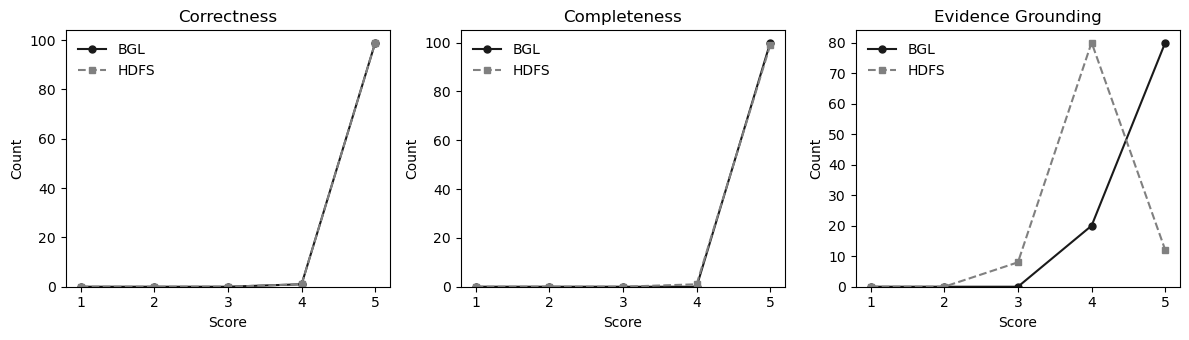

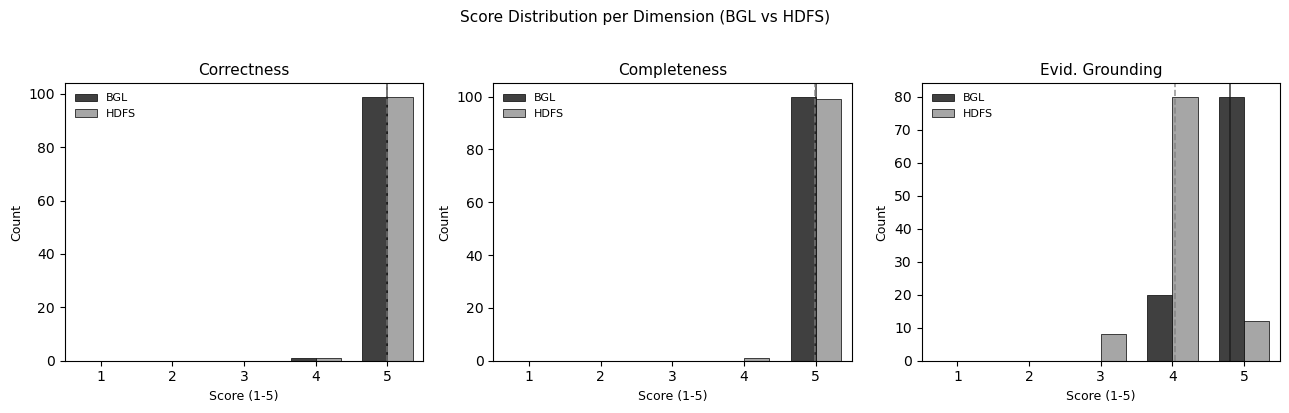

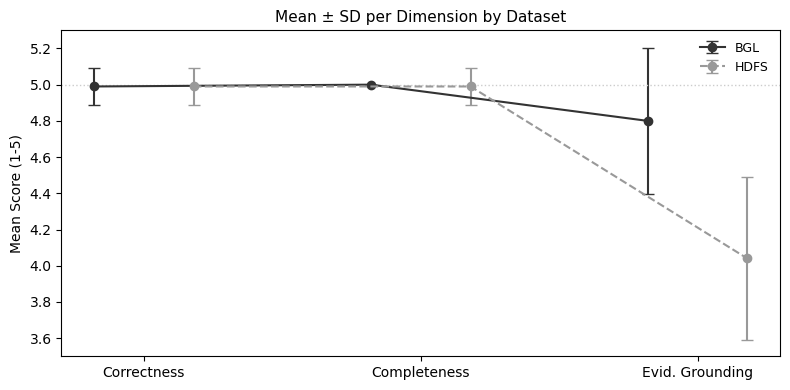

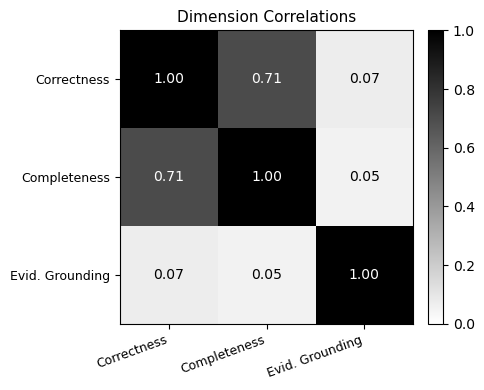

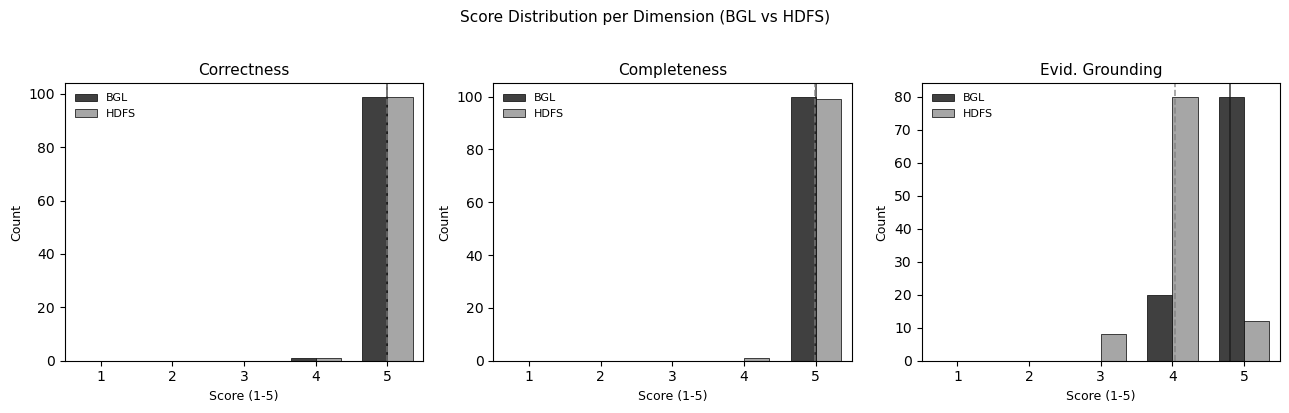

[OK] Saved: paper_human_eval_distribution.png


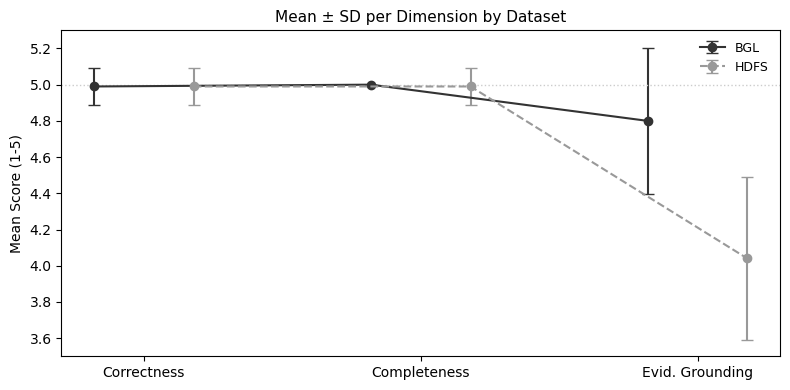

[OK] Saved: paper_human_eval_means.png


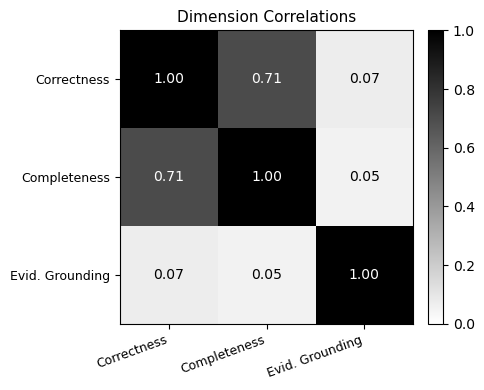

[OK] Saved: paper_human_eval_corr.png


In [25]:

# === Paper-Ready Table + Figures ===
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

# --- Table ---
print("=" * 90)
print(f"TABLE: Human Evaluation of Explanation Quality  (Likert 1-5, n={SAMPLE_SIZE} per dataset)")
print("=" * 90)
header = (f"| {'Dataset':<8} | {'n':>3} | {'Correctness':>15} | {'Completeness':>15} "
          f"| {'Evid. Grounding':>17} | {'Actionable':>11} |")
sep    = f"|{'-'*10}|{'-'*5}|{'-'*17}|{'-'*17}|{'-'*19}|{'-'*13}|"
print(header)
print(sep)
for ds in ['BGL', 'HDFS', 'Overall']:
    sub = df_r if ds == 'Overall' else df_r[df_r['dataset'] == ds]
    if sub.empty:
        continue
    n = len(sub)
    def fmt(col):
        return f"{sub[col].mean():.2f} +/- {sub[col].std():.2f}"
    act = f"{sub['actionable'].mean():.0%}"
    print(f"| {ds:<8} | {n:>3} | {fmt('correctness'):>15} | {fmt('completeness'):>15} "
          f"| {fmt('evidence_grounding'):>17} | {act:>11} |")

# --- Figure 1: Score distribution (stacked bar — BGL vs HDFS side by side) ---
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
scores = np.array([1, 2, 3, 4, 5])
x = np.arange(1, 6)
width = 0.35

for ax, dim in zip(axes, DIMS):
    bgl_counts  = np.array([
        (df_r[df_r.dataset == 'BGL'][dim] == s).sum() for s in scores])
    hdfs_counts = np.array([
        (df_r[df_r.dataset == 'HDFS'][dim] == s).sum() for s in scores])

    ax.bar(x - width/2, bgl_counts,  width, label='BGL',  color='0.25', edgecolor='black', linewidth=0.5)
    ax.bar(x + width/2, hdfs_counts, width, label='HDFS', color='0.65', edgecolor='black', linewidth=0.5)

    bgl_m  = df_r[df_r.dataset == 'BGL'][dim].mean()
    hdfs_m = df_r[df_r.dataset == 'HDFS'][dim].mean()
    ax.axvline(bgl_m,  color='0.1', linestyle='-',  linewidth=1.2, alpha=0.8)
    ax.axvline(hdfs_m, color='0.5', linestyle='--', linewidth=1.2, alpha=0.8)

    ax.set_title(DIM_LABELS[dim], fontsize=11)
    ax.set_xlabel('Score (1-5)', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.set_xticks(x)
    ax.set_xlim(0.5, 5.5)
    ax.set_ylim(bottom=0)
    ax.legend(frameon=False, fontsize=8)

plt.suptitle('Score Distribution per Dimension (BGL vs HDFS)', fontsize=11, y=1.02)
plt.tight_layout()
out1 = PROJECT_ROOT / 'results' / 'paper_human_eval_distribution.png'
fig.savefig(out1, dpi=600, bbox_inches='tight')
plt.show()
print(f"[OK] Saved: {out1.name}")

# --- Figure 2: Mean scores with std error bars + actionable % ---
fig2, ax2 = plt.subplots(figsize=(8, 4))
dim_labels_short = [DIM_LABELS[d] for d in DIMS]
x_pos = np.arange(len(DIMS))

for i, (ds, offset, gray, ls) in enumerate(
        [('BGL', -0.18, '0.2', '-'), ('HDFS', 0.18, '0.6', '--')]):
    sub = df_r[df_r.dataset == ds]
    means = [sub[d].mean() for d in DIMS]
    stds  = [sub[d].std()  for d in DIMS]
    ax2.errorbar(x_pos + offset, means, yerr=stds,
                 fmt='o', color=gray, linestyle=ls, linewidth=1.5,
                 capsize=4, markersize=6, label=ds)

ax2.set_xticks(x_pos)
ax2.set_xticklabels(dim_labels_short, fontsize=10)
ax2.set_ylabel('Mean Score (1-5)', fontsize=10)
ax2.set_ylim(3.5, 5.3)
ax2.axhline(5.0, color='0.8', linestyle=':', linewidth=1)
ax2.legend(frameon=False, fontsize=9)
ax2.set_title('Mean ± SD per Dimension by Dataset', fontsize=11)
plt.tight_layout()
out2 = PROJECT_ROOT / 'results' / 'paper_human_eval_means.png'
fig2.savefig(out2, dpi=600, bbox_inches='tight')
plt.show()
print(f"[OK] Saved: {out2.name}")

# --- Figure 3: Correlation heatmap (grayscale) ---
fig3, ax3 = plt.subplots(figsize=(5, 4))
corr_vals = df_r[DIMS].corr().values
im = ax3.imshow(corr_vals, cmap='gray_r', vmin=0, vmax=1)
ax3.set_xticks(range(3))
ax3.set_yticks(range(3))
ax3.set_xticklabels([DIM_LABELS[d] for d in DIMS], rotation=20, ha='right', fontsize=9)
ax3.set_yticklabels([DIM_LABELS[d] for d in DIMS], fontsize=9)
for i in range(3):
    for j in range(3):
        text_color = 'white' if corr_vals[i, j] > 0.6 else 'black'
        ax3.text(j, i, f"{corr_vals[i,j]:.2f}", ha='center', va='center',
                 fontsize=10, color=text_color)
plt.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)
ax3.set_title('Dimension Correlations', fontsize=11)
plt.tight_layout()
out3 = PROJECT_ROOT / 'results' / 'paper_human_eval_corr.png'
fig3.savefig(out3, dpi=600, bbox_inches='tight')
plt.show()
print(f"[OK] Saved: {out3.name}")
